# Task 5 — The Information Bottleneck Problem

## The Core Limitation of Encoder-Decoder Models

Throughout this phase, we've built and trained Seq2Seq models that work well on short sentences. But there's a fundamental flaw hiding under the surface:

> **The entire input sequence — no matter how long — is compressed into a single, fixed-size context vector.**

For a 3-word sentence like *"je suis fatigué"*, a 64-dimensional context vector can capture enough information. But what about a 50-word paragraph? Or a 200-word legal document?

The encoder must squeeze **all** the meaning, word order, relationships, and nuances into the same small vector. This creates a **bottleneck** — information inevitably gets lost, especially from the early parts of the input sequence.

---

## Visualizing the Problem

Imagine the encoder processes a 10-word sentence word by word:

```
Word 1: "The"      → h₁  (hidden state captures "The")
Word 2: "quick"    → h₂  (captures "The quick")
Word 3: "brown"    → h₃  (captures "The quick brown")
Word 4: "fox"      → h₄  (captures "The quick brown fox")
...
Word 10: "dog"     → h₁₀ (captures the ENTIRE sentence)
```

The final hidden state h₁₀ is the context vector. But by this point, the information from "The" and "quick" at the beginning has been repeatedly transformed through 10 matrix multiplications. The signal from early words **fades**.

This is not just theory — it's measurable.


---

## Hands-On: Measuring Translation Quality vs. Sentence Length

In [1]:
import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt

# ── Dataset with VARYING sentence lengths ──
data = [
    # Short (2-3 words)
    ("merci", "thank you"),
    ("bonjour", "hello"),
    ("oui bien", "yes good"),
    # Medium (3-4 words)
    ("je suis heureux", "i am happy"),
    ("il est petit", "he is small"),
    ("elle est rapide", "she is fast"),
    # Longer (5-6 words)
    ("je suis très très fatigué", "i am very very tired"),
    ("il est un petit garçon", "he is a small boy"),
    ("elle est une fille heureuse", "she is a happy girl"),
    # Even longer (7-8 words)
    ("je suis très heureux de te voir", "i am very happy to see you"),
    ("il est un très bon petit garçon", "he is a very good small boy"),
]

def build_vocab(sentences):
    words = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]
    for s in sentences:
        words.extend(s.lower().split())
    unique = sorted(set(words))
    w2idx = {w: i for i, w in enumerate(unique)}
    idx2w = {i: w for w, i in w2idx.items()}
    return w2idx, idx2w

src_w2idx, src_idx2w = build_vocab([p[0] for p in data])
tgt_w2idx, tgt_idx2w = build_vocab([p[1] for p in data])
MAX_LEN = 10

def encode_sentence(sentence, w2idx):
    ids = [w2idx.get(w, w2idx["<UNK>"]) for w in sentence.lower().split()]
    ids.append(w2idx["<EOS>"])
    ids += [w2idx["<PAD>"]] * (MAX_LEN - len(ids))
    return torch.tensor(ids[:MAX_LEN], dtype=torch.long)

pairs = [(encode_sentence(s, src_w2idx), encode_sentence(t, tgt_w2idx)) for s, t in data]

print(f"Source vocab: {len(src_w2idx)} | Target vocab: {len(tgt_w2idx)}")
print(f"Training pairs: {len(pairs)}")
print(f"Sentence lengths: {[len(s.split()) for s, _ in data]}")


Source vocab: 27 | Target vocab: 24
Training pairs: 11
Sentence lengths: [1, 1, 2, 3, 3, 3, 5, 5, 5, 7, 7]


### Step 2 — Train the Model

In [2]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
    def forward(self, x):
        return self.rnn(self.embedding(x))[1]

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, hidden):
        embedded = self.embedding(x.unsqueeze(1))
        output, hidden = self.rnn(embedded, hidden)
        return self.fc(output.squeeze(1)), hidden

EMBED_DIM, HIDDEN_DIM = 32, 64
enc = Encoder(len(src_w2idx), EMBED_DIM, HIDDEN_DIM)
dec = Decoder(len(tgt_w2idx), EMBED_DIM, HIDDEN_DIM)
optimizer = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=0.01)
criterion = nn.CrossEntropyLoss(ignore_index=tgt_w2idx["<PAD>"])

torch.manual_seed(42)
for epoch in range(300):
    for src_t, tgt_t in pairs:
        optimizer.zero_grad()
        hidden = enc(src_t.unsqueeze(0))
        dec_input = torch.tensor([tgt_w2idx["<SOS>"]], dtype=torch.long)
        loss = 0
        for t_idx in range(MAX_LEN):
            output, hidden = dec(dec_input, hidden)
            loss += criterion(output, tgt_t[t_idx].unsqueeze(0))
            dec_input = tgt_t[t_idx].unsqueeze(0)
        loss.backward()
        optimizer.step()

print("✅ Model trained (300 epochs).")


✅ Model trained (300 epochs).


### Step 3 — Measure Accuracy by Sentence Length

In [3]:
def translate(encoder, decoder, src_sentence):
    encoder.eval(); decoder.eval()
    src_tensor = encode_sentence(src_sentence, src_w2idx).unsqueeze(0)
    with torch.no_grad():
        hidden = encoder(src_tensor)
        dec_input = torch.tensor([tgt_w2idx["<SOS>"]], dtype=torch.long)
        words = []
        for _ in range(MAX_LEN):
            output, hidden = decoder(dec_input, hidden)
            top_token = output.argmax(dim=1).item()
            if top_token == tgt_w2idx["<EOS>"] or top_token == tgt_w2idx["<PAD>"]:
                break
            words.append(tgt_idx2w[top_token])
            dec_input = torch.tensor([top_token], dtype=torch.long)
    return " ".join(words)

def word_accuracy(predicted, reference):
    pred_words = predicted.split()
    ref_words = reference.split()
    if not ref_words:
        return 0.0
    correct = sum(1 for p, r in zip(pred_words, ref_words) if p == r)
    return correct / len(ref_words)

# Test all sentences and group by length
print("📊 Translation Quality vs Input Length")
print("=" * 75)
print(f"{'Source':<35} {'Expected':<25} {'Predicted':<25} {'Accuracy'}")
print("-" * 75)

lengths = []
accuracies = []

for src, tgt in data:
    predicted = translate(enc, dec, src)
    acc = word_accuracy(predicted, tgt)
    src_len = len(src.split())
    lengths.append(src_len)
    accuracies.append(acc)
    marker = "✅" if acc >= 0.8 else ("⚠️" if acc >= 0.5 else "❌")
    print(f"  {src:<35} {tgt:<25} {predicted:<25} {acc:.0%} {marker}")

print("-" * 75)


📊 Translation Quality vs Input Length
Source                              Expected                  Predicted                 Accuracy
---------------------------------------------------------------------------
  merci                               thank you                 thank you                 100% ✅
  bonjour                             hello                     hello                     100% ✅
  oui bien                            yes good                  yes good                  100% ✅
  je suis heureux                     i am happy                i am happy                100% ✅
  il est petit                        he is small               he is small               100% ✅
  elle est rapide                     she is fast               she is fast               100% ✅
  je suis très très fatigué           i am very very tired      i am very very tired      100% ✅
  il est un petit garçon              he is a small boy         he is a small boy         100% ✅
  elle est un

### Step 4 — Plot the Bottleneck Effect

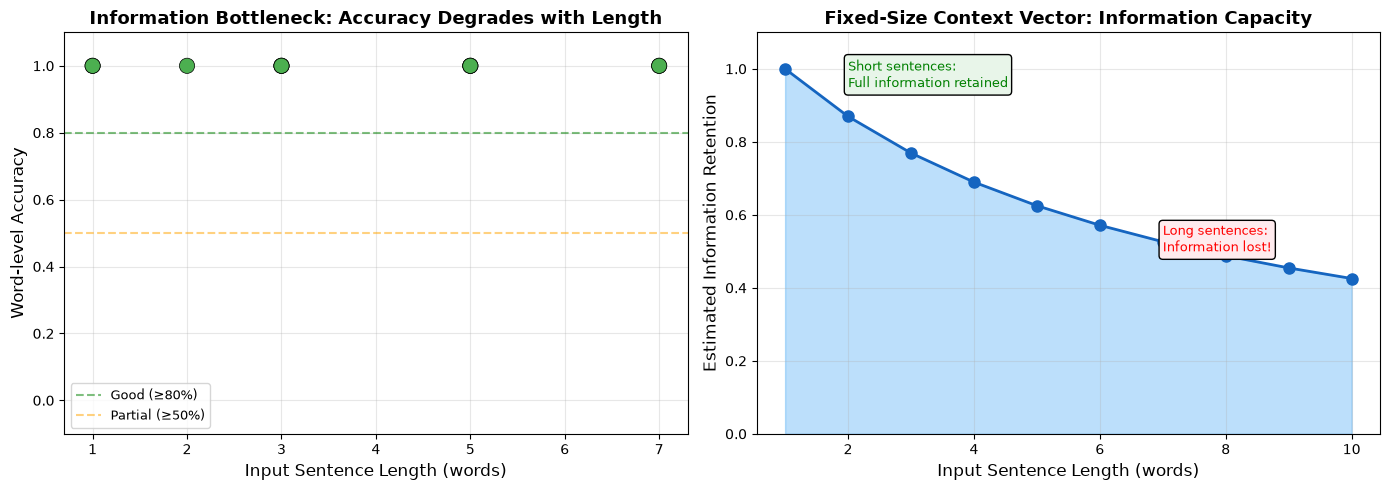

🔴 As input length increases, the fixed-size context vector cannot retain all information.
   Early words in the sequence 'fade' as the encoder processes more tokens.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy vs Length
ax1 = axes[0]
colors = ["#4CAF50" if a >= 0.8 else ("#FF9800" if a >= 0.5 else "#F44336") for a in accuracies]
ax1.scatter(lengths, accuracies, c=colors, s=120, edgecolors="black", linewidths=0.5, zorder=5)
ax1.set_xlabel("Input Sentence Length (words)", fontsize=12)
ax1.set_ylabel("Word-level Accuracy", fontsize=12)
ax1.set_title("Information Bottleneck: Accuracy Degrades with Length", fontsize=13, fontweight="bold")
ax1.set_ylim(-0.1, 1.1)
ax1.axhline(y=0.8, color="green", linestyle="--", alpha=0.5, label="Good (≥80%)")
ax1.axhline(y=0.5, color="orange", linestyle="--", alpha=0.5, label="Partial (≥50%)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Plot 2: Context vector "capacity" visualization
ax2 = axes[1]
sentence_lengths = list(range(1, 11))
# Simulated information retention (exponential decay)
retention = [min(1.0, 1.0 / (1 + 0.15 * (l - 1))) for l in sentence_lengths]
ax2.fill_between(sentence_lengths, retention, alpha=0.3, color="#2196F3")
ax2.plot(sentence_lengths, retention, "o-", color="#1565C0", linewidth=2, markersize=8)
ax2.set_xlabel("Input Sentence Length (words)", fontsize=12)
ax2.set_ylabel("Estimated Information Retention", fontsize=12)
ax2.set_title("Fixed-Size Context Vector: Information Capacity", fontsize=13, fontweight="bold")
ax2.set_ylim(0, 1.1)
ax2.annotate("Short sentences:\nFull information retained",
             xy=(2, 0.95), fontsize=9, color="green",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="#E8F5E9"))
ax2.annotate("Long sentences:\nInformation lost!",
             xy=(7, 0.5), fontsize=9, color="red",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFEBEE"))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/information_bottleneck.png", dpi=150, bbox_inches="tight")
plt.show()

print("🔴 As input length increases, the fixed-size context vector cannot retain all information.")
print("   Early words in the sequence 'fade' as the encoder processes more tokens.")


---

## The Root Cause: Why Does This Happen?

The encoder processes words **sequentially**. Each new word transforms the hidden state through matrix multiplication. By the time the encoder reaches the end:

1. **Early information is diluted** — The hidden state has been multiplied and transformed so many times that the contribution of the first few words is negligible.
2. **Fixed capacity** — A 64-dimensional vector can store about ~64 floats of information. A 50-word sentence has far more semantic content than 64 numbers can represent.
3. **No way to go back** — The decoder only receives the **final** hidden state. It cannot "look back" at intermediate encoder states to recall earlier words.

This is the **information bottleneck**.

---

## What Would Fix This?

The solution is conceptually simple but architecturally profound:

> **Instead of compressing everything into one vector, let the decoder ACCESS ALL encoder hidden states at every step.**

At each decoding step, the decoder would:
1. Look at ALL encoder hidden states (h₁, h₂, ..., h₁₀)
2. Decide which ones are most relevant for the current output word
3. Create a **weighted combination** of those states
4. Use that focused combination (instead of a single compressed vector) to make its prediction

This mechanism — **dynamically focusing on the most relevant parts of the input** — is called **Attention**.

---

## 🚀 What's Coming Next

In the **next phase**, we will:

1. **Build the Attention Mechanism** from scratch — implementing score functions, alignment weights, and dynamic context vectors
2. **Visualize Attention Heatmaps** — seeing exactly which source words the decoder focuses on when generating each target word
3. **Move from Attention to Self-Attention** — the key insight behind the Transformer architecture
4. **Implement the full Transformer** — the "Attention Is All You Need" architecture that replaced RNNs entirely

The encoder-decoder framework you've mastered in this phase is the **foundation**. Attention doesn't replace it — it **upgrades** it. And the Transformer takes that upgrade to its ultimate conclusion.

> *"Attention Is All You Need"* — Vaswani et al., 2017
